In [1]:
import pandas as pd

# Sample data
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]
}

df = pd.DataFrame(data)

In [2]:
df

,Month,Sales,Profit
0,Jan,10000,2000
1,Feb,12000,3000
2,Mar,15000,4000
3,Apr,13000,2500
4,May,17000,3500
5,Jun,16000,3000


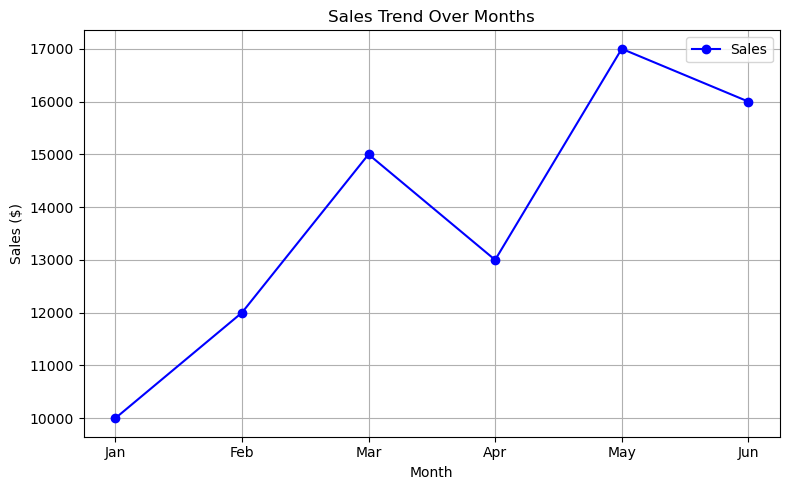

In [3]:
# 1- line plot sales over time

import matplotlib.pyplot as plt

# Line Plot: Sales over Time
plt.figure(figsize=(8, 5))
plt.plot(df['Month'], df['Sales'], color='blue', marker='o', linestyle='-', label='Sales')
plt.title('Sales Trend Over Months')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


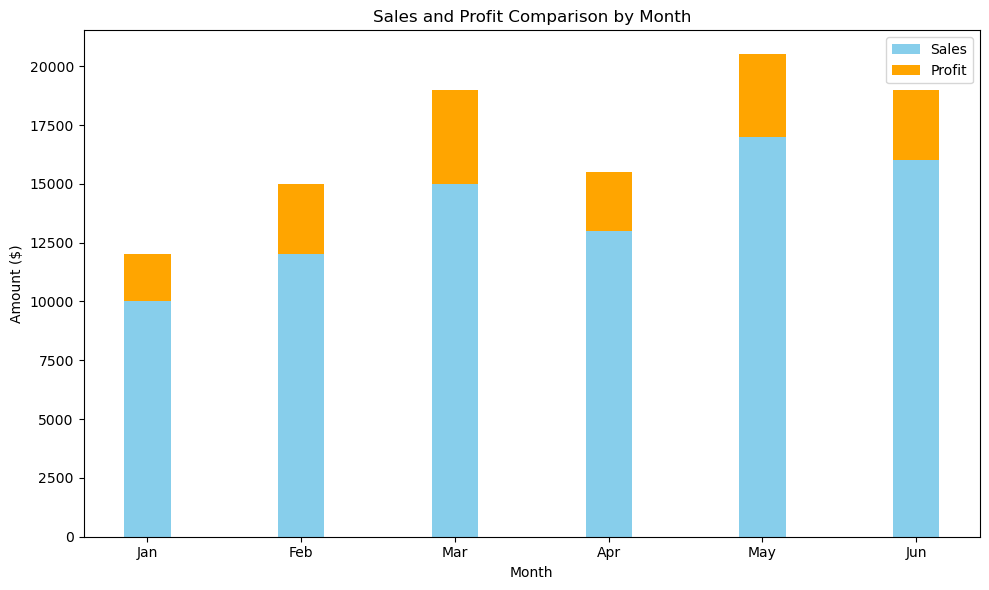

In [4]:
# Bar Plot: Sales vs Profit by Month
plt.figure(figsize=(10, 6))
width = 0.3
plt.bar(df['Month'], df['Sales'], width=width, label='Sales', color='skyblue')
plt.bar(df['Month'], df['Profit'], width=width, label='Profit', color='orange', bottom=df['Sales'])
plt.title('Sales and Profit Comparison by Month')
plt.xlabel('Month')
plt.ylabel('Amount ($)')
plt.legend()
plt.tight_layout()
plt.show()


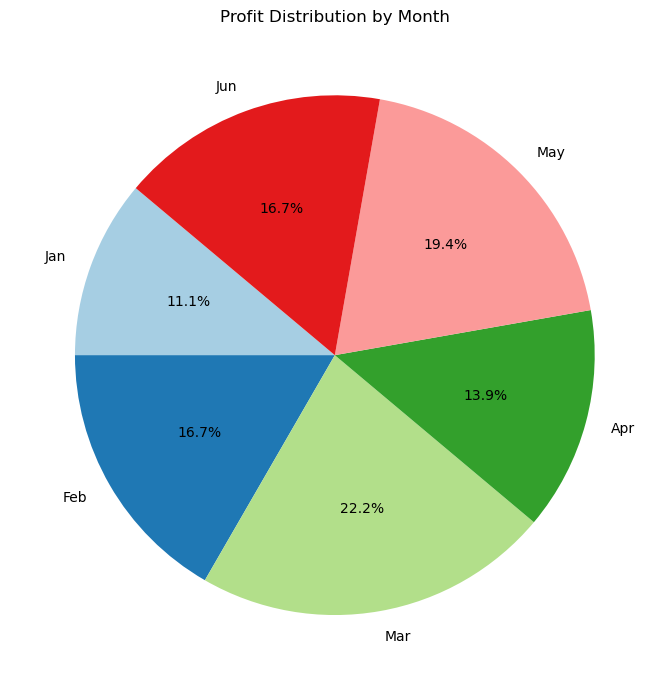

In [5]:
# Pie Chart: Profit Distribution by Month
plt.figure(figsize=(7, 7))
plt.pie(df['Profit'], labels=df['Month'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Profit Distribution by Month')
plt.tight_layout()
plt.show()


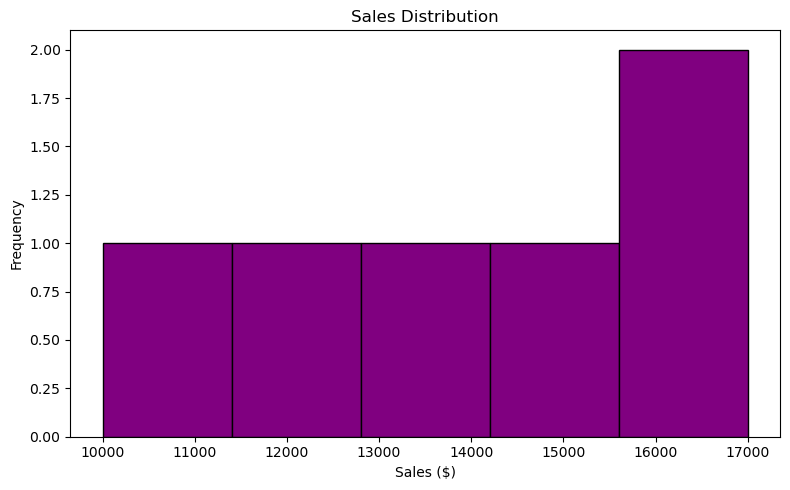

In [6]:
# Histogram: Distribution of Sales
plt.figure(figsize=(8, 5))
plt.hist(df['Sales'], bins=5, color='purple', edgecolor='black')
plt.title('Sales Distribution')
plt.xlabel('Sales ($)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

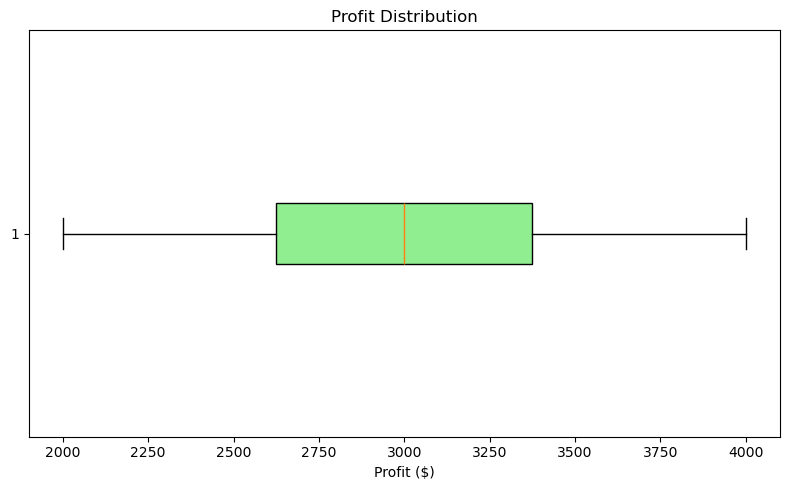

In [7]:
# Box Plot: Profit Distribution
plt.figure(figsize=(8, 5))
plt.boxplot(df['Profit'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
plt.title('Profit Distribution')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()

In [8]:
!pip install gradio

  Using cached gradio-6.11.0-py3-none-any.whl.metadata (17 kB)
  Using cached aiofiles-24.1.0-py3-none-any.whl.metadata (10 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached ffmpy-1.0.0-py3-none-any.whl.metadata (3.0 kB)
  Using cached gradio_client-2.4.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.3.0-py3-none-any.whl.metadata (404 bytes)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached gradio-6.11.0-py3-none-any.whl (36.8 MB)
Using cached gradio_client-2.4.0-py3-none-any.whl (59 kB)
Using cached aiofiles-24.1.0-py3-none-any.whl (15 kB)
Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl (30 kB)
Using cached groovy-0

In [9]:
import gradio as gr
import pandas as pd
import matplotlib.pyplot as plt

# Sample data
data = {
    "Month": ["Jan", "Feb", "Mar", "Apr", "May", "Jun"],
    "Sales": [10000, 12000, 15000, 13000, 17000, 16000],
    "Profit": [2000, 3000, 4000, 2500, 3500, 3000]
}
df = pd.DataFrame(data)

# Function to return selected plot
def generate_plot(plot_type):
    fig = plt.figure(figsize=(8, 5))

    if plot_type == "Line Plot":
        plt.plot(df['Month'], df['Sales'], color='blue', marker='o', label='Sales')
        plt.title('Sales Trend Over Months')
        plt.xlabel('Month')
        plt.ylabel('Sales ($)')
        plt.grid(True)
        plt.legend()

    elif plot_type == "Stacked Bar Chart":
        fig.set_size_inches(10, 6)
        width = 0.3
        plt.bar(df['Month'], df['Sales'], width=width, label='Sales', color='skyblue')
        plt.bar(df['Month'], df['Profit'], width=width, label='Profit', color='orange', bottom=df['Sales'])
        plt.title('Sales and Profit Comparison by Month')
        plt.xlabel('Month')
        plt.ylabel('Amount ($)')
        plt.legend()

    elif plot_type == "Pie Chart":
        fig.set_size_inches(7, 7)
        plt.pie(df['Profit'], labels=df['Month'], autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
        plt.title('Profit Distribution by Month')

    elif plot_type == "Scatter Plot":
        plt.scatter(df['Sales'], df['Profit'], color='green', s=100, edgecolors='black')
        plt.title('Sales vs Profit')
        plt.xlabel('Sales ($)')
        plt.ylabel('Profit ($)')
        plt.grid(True)

    elif plot_type == "Histogram":
        plt.hist(df['Sales'], bins=5, color='purple', edgecolor='black')
        plt.title('Sales Distribution')
        plt.xlabel('Sales ($)')
        plt.ylabel('Frequency')

    elif plot_type == "Box Plot":
        plt.boxplot(df['Profit'], vert=False, patch_artist=True, boxprops=dict(facecolor="lightgreen"))
        plt.title('Profit Distribution')
        plt.xlabel('Profit ($)')

    plt.tight_layout()
    return fig

# Gradio UI
demo = gr.Interface(
    fn=generate_plot,
    inputs=gr.Radio(
        ["Line Plot", "Stacked Bar Chart", "Pie Chart", "Scatter Plot", "Histogram", "Box Plot"],
        label="Choose Plot Type"
    ),
    outputs=gr.Plot(label="Visualization"),
    title="Sales & Profit Visual Explorer",
    description="Choose a chart type to visualize the data."
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

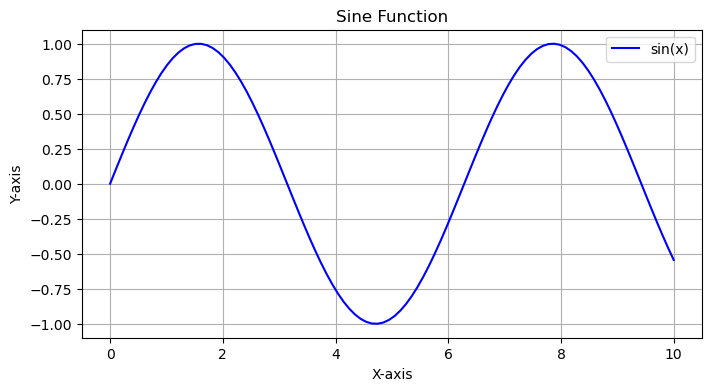

In [12]:
#line plot
x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.figure(figsize=(8, 4))
plt.plot(x, y, label="sin(x)", color='blue')
plt.title("Sine Function")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.legend()
plt.show()

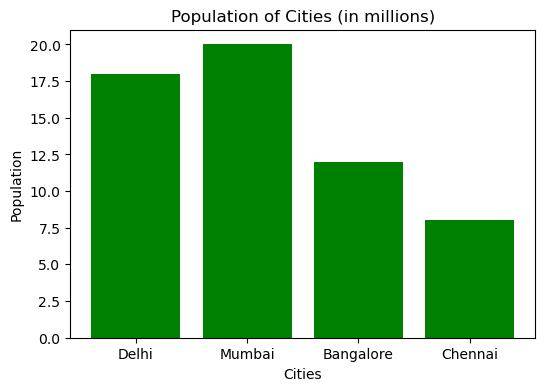

In [13]:

cities = ['Delhi', 'Mumbai', 'Bangalore', 'Chennai']
population = [18, 20, 12, 8]

plt.figure(figsize=(6,4))
plt.bar(cities, population, color='green')
plt.title("Population of Cities (in millions)")
plt.xlabel("Cities")
plt.ylabel("Population")
plt.show()

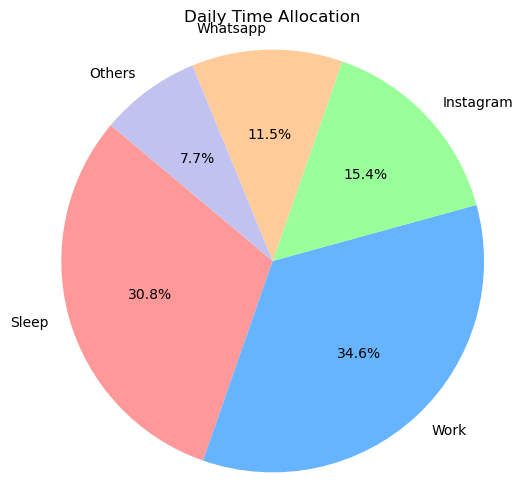

In [17]:
#pie chart
labels = ['Sleep', 'Work', 'Instagram', 'Whatsapp', 'Others']
sizes = [8, 9, 4, 3, 2]
colors = ['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0']

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Daily Time Allocation")
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

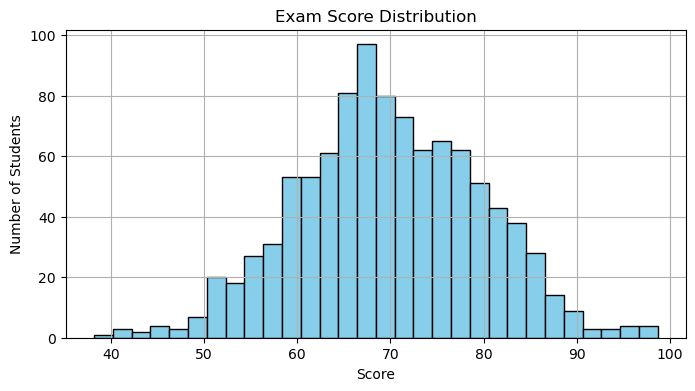

In [18]:
#histogarm
scores = np.random.normal(loc=70, scale=10, size=1000)

plt.figure(figsize=(8,4))
plt.hist(scores, bins=30, color='skyblue', edgecolor='black')
plt.title("Exam Score Distribution")
plt.xlabel("Score")
plt.ylabel("Number of Students")
plt.grid(True)
plt.show()

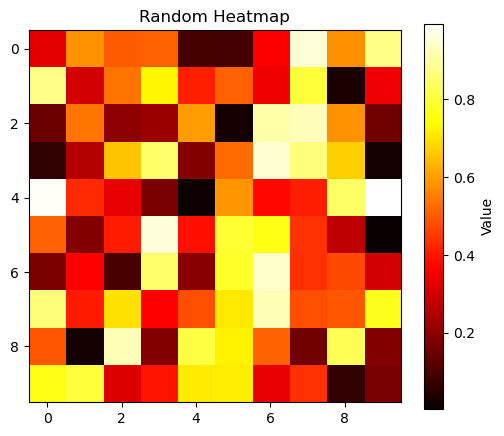

In [19]:
#heatmap
data = np.random.rand(10, 10)

plt.figure(figsize=(6, 5))
plt.imshow(data, cmap='hot', interpolation='nearest')
plt.colorbar(label='Value')
plt.title("Random Heatmap")
plt.show()